In [1]:
library(tidyverse)

Warning message:
“package ‘tibble’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/lib/libopenblasp-r0.3.20.dylib

locale:
[1] en_GB.UTF-8/en_GB.UTF-8/en_GB.UTF-8/C/en_GB.UTF-8/en_GB.UTF-8

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lubridate_1.9.3 forcats_1.0.0   stringr_1.5.1   dplyr_1.1.4    
 [5] purrr_1.0.2     readr_2.1.5     tidyr_1.3.1     tibble_3.2.1   
 [9] ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] pillar_1.10.2      compiler_4.2.1     RColorBrewer_1.1-3 base64enc_0.1-3   
 [5] tools_4.2.1        digest_0.6.36      uuid_1.2-0         timechange_0.3.0  
 [9] jsonlite_1.8.8     evaluate_1.0.3     lifecycle_1.0.4    gtable_0.3.6      
[13] pkgconfig_2.0.3    rlang_1.1.4        IRdisplay_1.1      cli_3.6.3         
[17] IRkernel_1.3.2     fastmap_1.2.0      

In [ ]:
sequences <- list.files(path = "ncbi-virus-fasta/", pattern = "sequences.*.fasta", full.names = TRUE) %>%
    map_df(~{
        # Only read header lines (starting with '>') to be more efficient
        read_lines(.x) %>%
            .[grepl("^>", .)] %>%  # Filter only header lines
            enframe(name = NULL, value = "line") %>%
            mutate(file = .x) %>%
            # Parse pipe-separated header information
            separate(line, into = c("accession_part", "remaining"), sep = "\\|", extra = "merge", fill = "right")
    })%>%
    mutate(
                Accession = gsub("^>", "", accession_part),  # Remove '>' from accession
                segment = ifelse(grepl("|[LSM1-9]{1}",remaining, fixed=TRUE), sub(".*\\|", "", remaining), NA),
                species = gsub(".*_([A-Z]+[1-9]?).fasta","\\1", file),
    )%>%
    select(Accession, segment, species)
head(sequences)

Accession,segment,species
<chr>,<lgl>,<chr>
NC_005300.2,NA,CCHF
NC_005301.3,NA,CCHF
NC_005302.1,NA,CCHF
PQ031235.1,NA,CCHF
PQ031237.1,NA,CCHF
PP729064.1,NA,CCHF


In [11]:
sequences %>%group_by(species, segment) %>% summarise(n=n())

`summarise()` has grouped output by 'species'. You can override using the
`.groups` argument.


species,segment,n
<chr>,<lgl>,<int>
CCHF,NA,389
EBOV,NA,606
FLU,NA,2000
HIV1,NA,2000
LASV,NA,82
MPX,NA,2000
RSV,NA,2000
SARS2,NA,2000
WNV,NA,2422


In [5]:
set.seed(42)
seed_references <- sequences %>% filter(Nuc_Completeness == "complete") %>% group_by(Organism_Name,Segment) %>% sample_n(1)

In [6]:
write_csv(seed_references, "seed-references.csv")

In [10]:
seed_references%>% group_by(Organism_Name)%>%
    summarise(n=n())

Organism_Name,n
<chr>,<int>
Ebola virus,1
Human immunodeficiency virus,1
Human respiratory syncytial virus,1
Influenza A virus,8
Mammarenavirus lassaense,2
Monkeypox virus,1
Orthonairovirus haemorrhagiae,4
Respiratory syncytial virus,1
Severe acute respiratory syndrome coronavirus 2,1


In [9]:
writeLines(sequences %>% filter(Nuc_Completeness == "complete")%>%pull(Accession), "complete-references.accessions.csv")
write_csv(sequences %>% filter(Nuc_Completeness == "complete"), "complete-references.csv")

Going to [batch-entrez](https://www.ncbi.nlm.nih.gov/portal/utils/batchentrez_p.cgi), uploading the file `complete-references.accessions.csv` to download all complete genomes in fasta format.

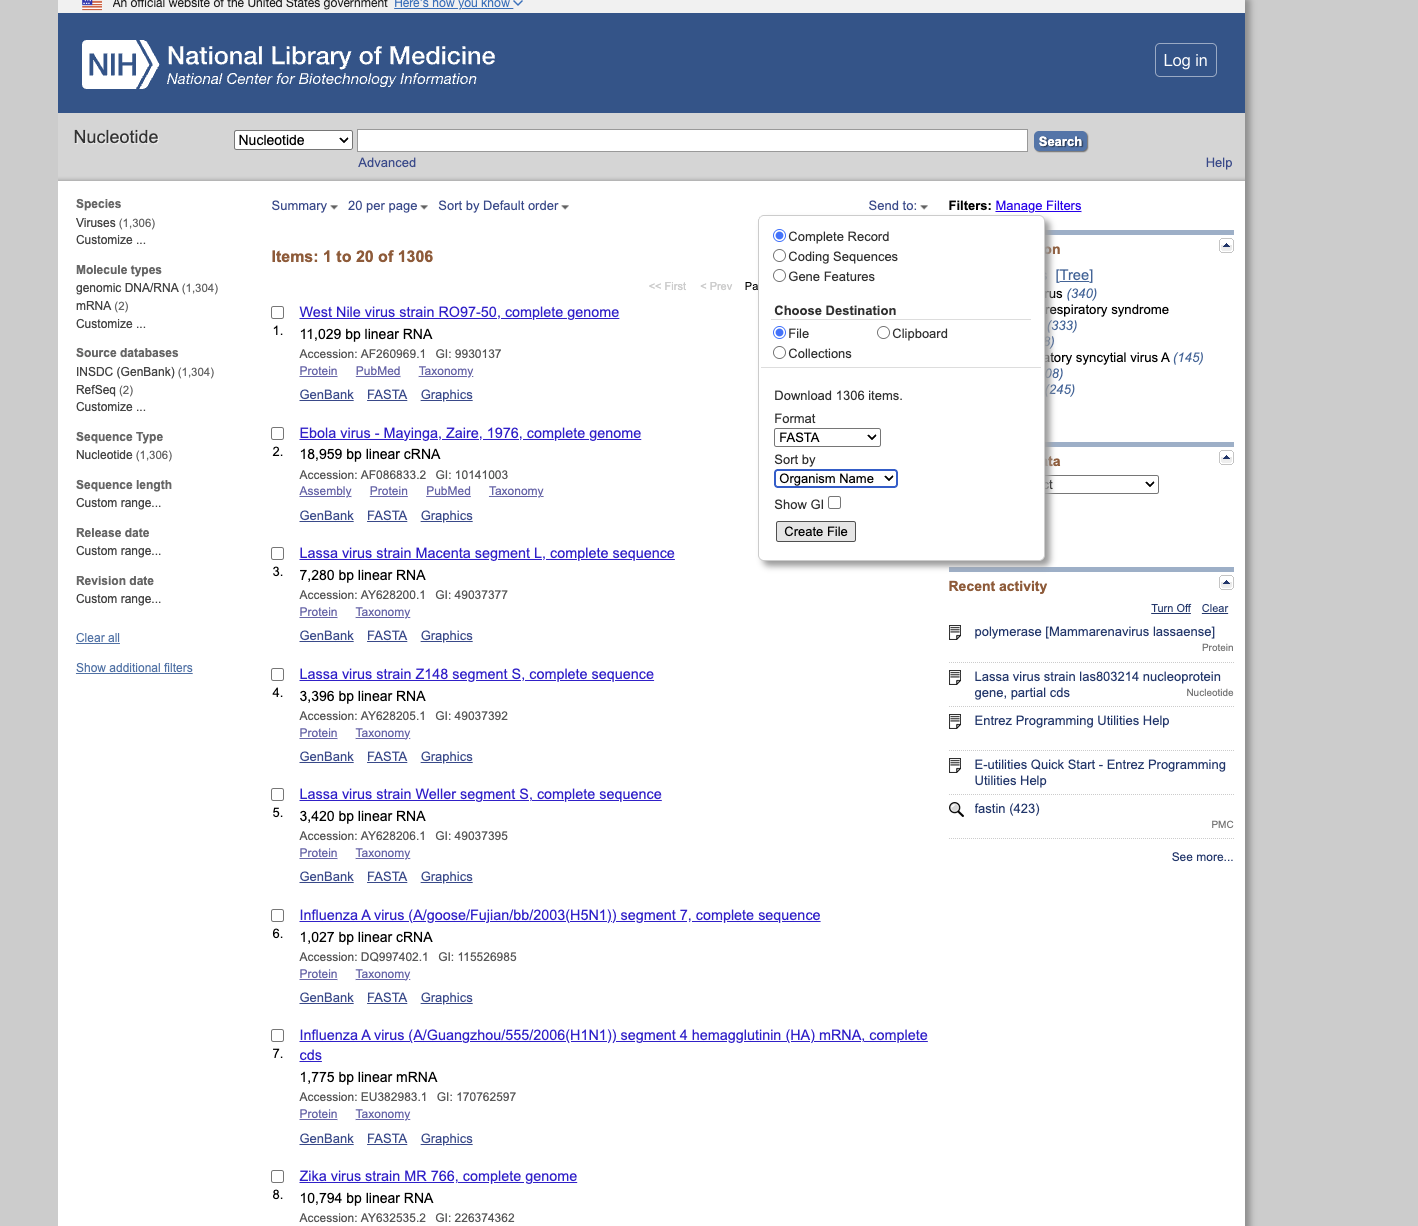


**Stored the file as `complete-references.fasta`.**


In [ ]:
writeLines(seed_references$Accession, "seed-references.accessions.csv")
system("seqkit grep -r -f seed-references.accessions.csv complete-references.fasta > seed-references.fasta", intern = TRUE)

character(0)